**Week 2 SBI library + experiments** \
Date: 25/07/09 \
Objectives:
- SBI library explorations 
- Simple experiments

**SBI lib explorations** \
following official sbi documentations, cont. from week 1

**Amortised NPE**  \
The two sets of data simulated with distinct parameters $\theta$ both evaluated and plotted to show the posteriors are evaluated well enough to indicate where the 'true parameter' (in this case sampled from the prior rather than a real theoretical value). Using amortised inference network allows fast evaluation of different observational data even those not used for training the network to begin with, as long as the prior and simulator remain the same for the new data, therefore reducing computational cost for future data processing.

In [1]:
#Amortised Gaussian, training stage
import numpy as np
import matplotlib.pyplot as plt
import torch

from sbi import analysis as analysis
from sbi import utils as utils
from sbi.inference import SNPE, simulate_for_sbi, prepare_for_sbi
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)

#Define the simulator and prior
num_dim = 3
def simulator(theta):
    #simulated data from a gaussian noise
    return theta + torch.randn_like(theta) * 0.1 + 1  

prior = utils.BoxUniform(-2*torch.ones(num_dim),2*torch.ones(num_dim))

#check simulated data and prior inputs
simulator, prior = prepare_for_sbi(simulator, prior)

#inference
inference = SNPE(prior=prior)
num_sim = 10000

#simulations
theta = prior.sample((num_sim,))
x = simulator(theta)
inference = inference.append_simulations(theta, x)

density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 78 epochs.

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

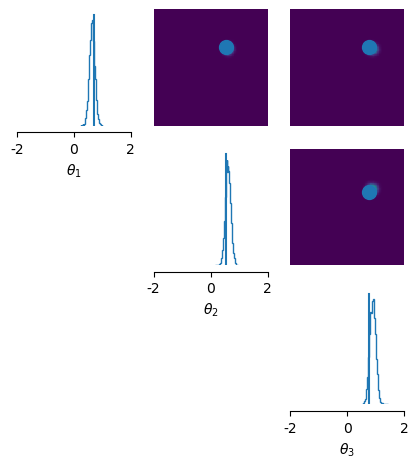

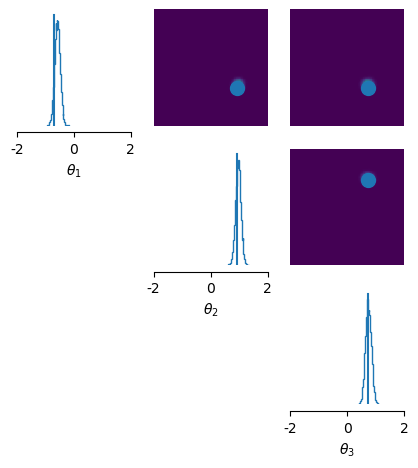

In [2]:
#Applying two sets of distinct observations
theta_1 = prior.sample((1,))
xobs_1 = simulator(theta_1)

theta_2 = prior.sample((1,))
xobs_2 = simulator(theta_2)

#without running twice the inference step, we can generate two sets of 'observed' data, xobs_1 and xobs_2
#and evaluate posteriors given the two parameters theta_1 and theta_2

posterior_samples_1 = posterior.sample((10000,), x=xobs_1)

#plot posterior samples
_ = analysis.pairplot(
    posterior_samples_1, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(5, 5),
    labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"],
    points=theta_1
)

posterior_samples_2 = posterior.sample((10000,), x=xobs_2)

# plot posterior samples
_ = analysis.pairplot(
    posterior_samples_2, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(5, 5),
    labels=[r"$\theta_1$", r"$\theta_2$", r"$\theta_3$"],
    points=theta_2
)

**Multi-round NPE** \
used when interested in very few number of sets of observational data, therefore can train the network multiple times to get a better posterior estimation. \
Process goes: prior+simulator --> posterior + simulated data from data --> input simulated data to train posterior again --> draw more data from the new posterior--> train posterior again... until a desired accuracy is achieved.

In [3]:
#use the same prior and simulator models from before
num_dim=3

def simulator(theta):
    #simulated data from a gaussian noise
    return theta + torch.randn_like(theta) * 0.1 + 1  

prior = utils.BoxUniform(-2*torch.ones(num_dim),2*torch.ones(num_dim))

#check simulated data and prior inputs
simulator, prior = prepare_for_sbi(simulator, prior)

#inference
inference = SNPE(prior=prior)
num_sim = 500

num_rounds = 2 #train two rounds

x_o = torch.zeros(num_dim,)  #infer the posterior around this 'observation' point, ie conditioning on this data
#will cause different outcomes of posterior if conditioned on different x_o

posteriors = [] #initialise posterior
proposal = prior #initialise proposal distribution to be the prior 
thetas = []

for _ in range(num_rounds):
    theta, xobs = simulate_for_sbi(simulator=simulator, proposal=proposal, num_simulations=500)
    inference = inference.append_simulations(theta, xobs, proposal=proposal)  #simulate and train the model based on the proposal function 
    #which will be updated at the end of loop
    density_estimator = inference.train()
    posterior = inference.build_posterior(density_estimator)
    posteriors.append(posterior)
    proposal = posterior.set_default_x(x_o)  #update proposal for the next round as posterior estimated
    #new data is then simulated from the posterior
    thetas.append(theta)

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

 Neural network successfully converged after 99 epochs.

Drawing 500 posterior samples:   0%|          | 0/500 [00:00<?, ?it/s]

Running 500 simulations.:   0%|          | 0/500 [00:00<?, ?it/s]

Using SNPE-C with atomic loss
 Neural network successfully converged after 30 epochs.

Drawing 10000 posterior samples:   0%|          | 0/10000 [00:00<?, ?it/s]

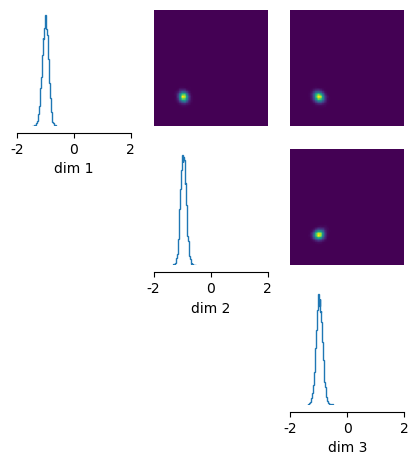

In [4]:
#visualisation
posterior_samples = posterior.sample((10000,), x=x_o)

_ = analysis.pairplot(
    posterior_samples, limits=[[-2, 2], [-2, 2], [-2, 2]], figsize=(5, 5)
)